<a href="https://colab.research.google.com/github/jlloring/ST-554_JLoring/blob/main/Loring_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ST 554 Homework 5**
---
Authored by: Jamie Loring

In [ ]:
# importing required modules:
import pandas as pd
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import sqlite3
from sklearn import linear_model

## **Part 1: Concepts**

#### **Question 1**
An example of a place where I have encountered big data is with the popular music streaming service, Spotify.
- **Volume:** Spotify handles a large scale of data in terms of its users, the songs that are streamed, the playlists that are created, the songs that are liked, etc.
- **Velocity:** Spotify streams its data in real time. *Discover Weekly* playlists are curated each week based on a user's listening history. When a song is skipped, this effects future recommendations. All listening habits are tracked to provide dynamic and personalized recommendations for future listening.
- **Variety:** Spotify handles different forms of data. In addition to each unique user profile, there are also different subscription plans. Users can create their own playlists and even share them with others in a collaborative manner. In addition to songs, Spotify also has podcasts available.
- **Veracity (Variability):** This V comes into play when Spotify's algorithm gets it wrong. Besides the obvious variation in filtering out bots/fake users, if the metadata is incorrect, this can negatively impact a user's recommendations. This can lead to inaccurate personalization of one's profile.
- **Value:** Spotify is a valuable form of big data. As a user myself, I particularly enjoy the *Discover Weekly* playlist because it exposes me to new music based on songs that I have liked. It also recommends new artists based on the ones that I have listened to. The data that Spotify collects allows it to personalize each user's experience, which makes it invaluable.

#### **Question 2**
The database that we will use in part IV consists of Major League Baseball (MLB) data. Common database actions are represented by the `CRUD` acronym:
- **C**reate data: An example of this would be adding a new person (presumably a player) into the `Person` table.
- **R**ead data: An example of this would be running a query to return all pitchers who have pitched at least 3 complete games within their season.
- **U**pdate data: An example of this would be updating any data that is incorrect, i.e., fixing a typo with the correct name of an MLB park.
- **D**elete data: An example of this would be removing a duplicate player entry from the `Person` table.

#### **Question 3**
The purpose of the `HAVING` clause when writing SQL code is similar to the `WHERE` clause in that it specifies a filter condition, but there are key differences these two clauses. `HAVING` goes *AFTER* the `GROUP BY` clause, but `WHERE` goes before the `GROUP BY` clause. Furthermore, if a `HAVING` clause is used, a `GROUP BY` clause must be used as well. This is not true with a `WHERE` clause; this can be used with or without `GROUP BY`. Since `HAVING` goes after the `GROUP BY` clause, the filtering is done on groups rather than individual rows (as this is the case with `WHERE`). As a result, the `HAVING` clause can accomodate aggregate functions used in the `SELECT` statement, but the `WHERE` clause cannot.

## **Part 2: Simulation of a Sampling Distribution**

#### **Question 4**
This question deals with simulating the sampling distribution of the slope from a simple linear regression model.

The code below was provided in the homework assignment. I copy it here for completeness.

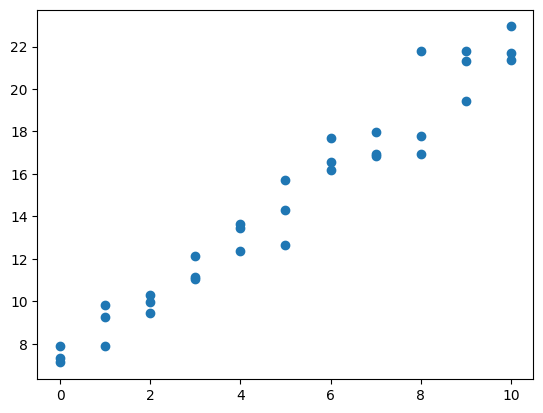

In [ ]:
#modules already imported at beginning of notebook
rng= default_rng(32)
beta_0= 7
beta_1= 1.5
# get three'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start= 0, stop= 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y= beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x= x, y= y)
plt.show()

Now, we are tasked with repeating the above process 5000 times to obtain a sampling distribution of the slope. The code below re-copies the defaults given for convenience and creates a regression object using `sklearn`. Then, a `for` loop is used to generate a y value using the default inputs, fit the regression model, and store the value of the slope -- 5000 times! The slopes are saved in a `numpy` array, initialized as an array of zeros, called `slopes`.

In [ ]:
# defaults given
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
x = np.array(list(np.linspace(start= 0, stop= 10, num = 11))*3)
n = 33

# create regression object
reg = linear_model.LinearRegression()

# initialize a numpy array of 5000 zeros (faster than using an empty list!)
slopes = np.zeros(5000)

# uses a for loop to generate the y values, fit the model with sklearn, and store the slope coefficients in a numpy array
for i in range(5000):
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    reg.fit(x.reshape(-1,1), y)
    #print(reg.intercept_, reg.coef_)
    slopes[i] = reg.coef_[0]

Next, we create a histogram of our `slopes` object so we can get an idea of its sampling distribution. The code below uses `matplotlib` to create such a histogram.

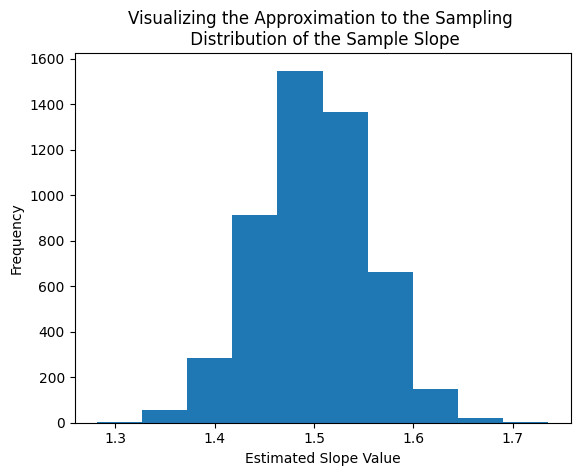

In [ ]:
plt.hist(slopes)
plt.title("Visualizing the Approximation to the Sampling \n Distribution of the Sample Slope")
plt.xlabel("Estimated Slope Value")
plt.ylabel("Frequency")
plt.show() #eliminates printed text output that is not needed

We can use our `slopes` array to approximate the probability of observing a sample slope larger than 1.65. The code `slopes > 1.65` will yield an array of True/False values. Since `True` takes on a value of 1, we can sum up this output to find the number of simulated slopes that exceed 1.65. Then, we can divide this number by 5000, our total number of simulated slopes, to obtain the probability.

In [ ]:
(slopes > 1.65).sum() / 5000

np.float64(0.0038)

Thus, the probability of observing a sample slope larger than 1.65, which was found by looking at the proportion of simulated values larger than 1.65, is approximately 0.0038.

This value of 0.0038, the probability of observing a sample slope larger than 1.65, is representative of the p-value in relation to a hypothesis test. This value tells us the probability of observing a result (a slope) as extreme or more extreme (larger) than 1.65. Since this probability is extremely low, if we did observe such a result (a slope), it would be deemed statistically significant.

## **Part 3: Big Data Examples & Rare Events**

#### **Question 5**
From the *Selection biases* section of the article, one example mentioned is a machine learning (ML) model used by criminal analysts to identify patterns. The issue around the data used to fit the model comes from coverage bias, specifically undercoverage, if certain data is left out. As mentioned in the article, failing to include data consisting of crimes committed against children, for example, means the model would suffer from coverage bias and fail to detect patterns of these types of crimes. Since machine learning models are trained on the data provided, it is important to have data of virtually all types of crimes for such a model to be reliable.

In the situation described above, we can account for such bias by making sure all resources are exhausted in collecting a well-rounded dataset. There is a difference in types of data not being available and not having the resources to search for such data. However, it's possible that certain types of crimes (such as crimes committed against children) are under-reported due to their sensitivity. In this case, the data could be augmented by looking to multiple sources, such as police records, court records, etc.

*Reference:* [Biases in machine learning models and big data analytics: The international criminal and humanitarian law implications](https://international-review.icrc.org/articles/biases-machine-learning-big-data-analytics-ihl-implications-913)

#### **Question 6**

Of the three major areas discussed in the paper, I will choose to focus on oceanography.

- **Volume:** Massive amounts of ocean data are made available through satellites, boats, submarines, etc. We also know that the majority of Earth is covered by the ocean, which helps contextualize just how much data is being collected.
- **Velocity:** I infer that satellites are able to transmit data rather quickly. Perhaps there are objects in the water, such as buoys, that are able to pick up live data entries.
- **Veracity (Variability):** Variability and uncertainty come from the fact that no data collection method is perfect. We can expect there to be inaccuracies in measurements if sensors aren't working properly or if there is a big storm, for example.
- **Variety:** When thinking about the ocean, there are many different data types that we can collect. Besides physical values such as temperature, current direction, and wave height, for example, we can also collect data on living creatures living in the ocean.
- **Value:** Ocean data can be used to give us a more-informed picture of our overall climate. Hurricanes are a great example of this, since they form in our oceans/bodies of water. Having big data on our oceans can help with predictions and tracking. Ocean data can also be used to provide insights on marine life.

Based on the breakdown of the five V's of big data above, while I don't believe there are really any biases present, there is the possibility for missing data to affect results. As mentioned previously when talking about **Veracity (Variability)**, it is theoretically possible for data to be missing if bad weather either clouds sensors or destroys equipment altogether.

It is important to consider the above points when thinking about how data is collected so that thought-provoking questions can be asked!

*Reference:* [Big data in Earth science: Emerging practice and promise](https://www.science.org/doi/10.1126/science.adh9607)

#### **Question 7**
Another scenario where understanding rare events is important is in the realm of natural disasters.

## **Part 4: Querying a database**

#### **Question 8**

The code below connects to the database that is uploaded to Colab. This file must be re-uploaded to the *Files* section at the start of each new session!

In [ ]:
con = sqlite3.connect("lahman_1871-2022.sqlite")

Continuing on, the code below looks at all the tables in the database. In addition, the `read_sql()` function from `pandas` is used to have this result returned as a data frame.

In [ ]:
#SQL query to return all table names in the database
get_schema = '''
             select *
             from sqlite_schema
             where type = 'table';
             '''
#puts result of SQL query into pandas df -- don't need a cursor object!
schema_df = pd.read_sql(get_schema, con)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


#### **Question 9**
The code below writes an SQL query with `pd.read_sql()` to return all the teams that played in 2015. All columns from the `Teams` table are returned.

In [ ]:
q9 = '''
     select *
     from Teams
     where yearID = 2015;
     '''

teams_2015 = pd.read_sql(q9, con)
teams_2015

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


#### **Question 10**
The code below writes an SQL query with `pd.read_sql()` to return all of the players in the hall of fame, the year they were voted into the hall of fame, and their category. A `WHERE` clause is used to make sure we are only pulling players that were actually inducted into the hall of fame!

In [ ]:
q10 = '''
      select playerID, yearid, category
      from HallOfFame
      where inducted = 'Y';
      '''

HOF = pd.read_sql(q10, con)
HOF

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


#### **Question 11**
The code below writes an SQL query with `pd.read_sql()` to return all unique managers of the Pittsburgh Pirates and only that information from the `Managers` table.

In [ ]:
q11 = '''
      select distinct playerID
      from Managers
      where teamID = 'PIT';
      '''

mgr = pd.read_sql(q11, con)
mgr

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


#### **Question 12**
The code below writes SQL code that uses the `HallOfFame` and `Managers` tables to return all of the `playerIDs` for the people that managed for a team that were inducted into the hall of fame. Since we just want to return `playerIDs`, `SELECT DISTINCT` will be used to ensure no duplicates are obtained. Since we want people who managed for a team _**AND**_ were inducted into the hall of fame, an `INNER JOIN` will be used to return records with matching keys in both tables. We also need to filter on `inducted = 'Y'` from the `HallOfFame` table to make sure we are returning people who were actually inducted into the hall of fame!

In [ ]:
q12 = '''
      select distinct m.playerID
      from Managers as m
      inner join
      HallOfFame as h
      on m.playerID = h.playerID
      where h.inducted = 'Y';
      '''

manager_HOF = pd.read_sql(q12, con)
manager_HOF

,playerID
0,alstowa01
1,andersp01
2,ansonca01
3,applilu01
4,baineha01
...,...
92,willidi02
93,willite01
94,wrighge01
95,wrighha01


The above code reveals there are 97 people that managed for a team that were inducted into the hall of fame. This number can be returned programmatically from the `manager_HOF` dataframe in several ways. I will use the `.count()` method.

In [ ]:
manager_HOF.count()

,0
playerID,97


#### **Question 13**
The code below writes an SQL query that uses the `HallOfFame` and `Managers` tables to return every season managed by each manager that made it to the hall of fame. This is different from the previous question, *Question 12*, because we want to return _**every season**_ for each manager that made it to the hall of fame, not just one record per manager. Thus, we will not use `DISTINCT` after the `SELECT` statement. The same `WHERE` clause, however, will remain. We are also instructed to return four specific variables from the `Managers` table:
- `playerID`
- `G`
- `W`
- `L`

In [ ]:
q13 = '''
      select m.playerID, m.G, m.W, m.L
      from Managers as m
      inner join
      HallOfFame as h
      on m.playerID = h.playerID
      where h.inducted = 'Y';
      '''

manager_season_HOF = pd.read_sql(q13, con)
manager_season_HOF

,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83
...,...,...,...,...
991,wrighha01,46,22,23
992,wrighha01,138,68,69
993,wrighha01,155,87,66
994,wrighha01,133,72,57


Next, we will create a new dataframe that determines the overall win/loss records (sum of wins and sum of losses) for each of these hall
of fame managers. A new variable that represents the overall win/loss percentage will also be created. I will do this in `pandas` using the returned data from the previous code section.

In [ ]:
# sums wins and losses by manager
mgr_szn_HOF_totals = manager_season_HOF.groupby("playerID")[['W', 'L']].sum()

# creates win/loss percentage variable using the formula provided
mgr_szn_HOF_totals["W/L %"] = (mgr_szn_HOF_totals.W) / (mgr_szn_HOF_totals.W + mgr_szn_HOF_totals.L)

# outputs aggregated dataframe
mgr_szn_HOF_totals

,W,L,W/L %
playerID,,,
alstowa01,2040,1613,0.558445
andersp01,2194,1834,0.544687
ansonca01,1296,947,0.577798
applilu01,10,30,0.250000
baineha01,1,3,0.250000
...,...,...,...
willidi02,1571,1451,0.519854
willite01,273,364,0.428571
wrighge01,59,25,0.702381


**Note:** The number of rows in `mgr_szn_HOF_totals` matches the number of player IDs returned from Question 12! This makes sense since we are grouping total wins and losses by each manager who was inducted into the hall of fame, and Question 12 returns each unique manager that meets this criteria!